In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
from matplotlib.ticker import LogLocator

In [2]:
M  = 15*15
Lp = 10

es = 0.1
eb = 0.4
er = 0.9

Is = 0.01
Ic = 0.01
m  = 0.005
k  = 0.0005

r = 0.015
c = 1.0

In [3]:
D  = []
v0 = []
Dt = []
Ic = []

A1 = []
A2 = []
E1 = []
E2 = []
S1 = []
S2 = []
N1 = []
N2 = []
P1 = []
P2 = []
Q1 = []
Q2 = []

In [4]:
datos1=[]
datos2=[]
datos3=[]
datos4=[]
datos5=[]
datos6=[]
datos7=[]
datos8=[]
datos9=[]
datos10=[]
datos11=[]
datos12=[]
datos13=[]
datos14=[]
datos15=[]
datos16=[]

file=open('FinalState.txt','r')
content=file.readlines()
for i in range (0,len(content),1):
   dato1  = content[i].find(', ')
   dato2  = content[i].find(', ', dato1  + 1)
   dato3  = content[i].find(', ', dato2  + 1)
   dato4  = content[i].find(', ', dato3  + 1)
   dato5  = content[i].find(', ', dato4  + 1)
   dato6  = content[i].find(', ', dato5  + 1)
   dato7  = content[i].find(', ', dato6  + 1)
   dato8  = content[i].find(', ', dato7  + 1)
   dato9  = content[i].find(', ', dato8  + 1)
   dato10 = content[i].find(', ', dato9  + 1)
   dato11 = content[i].find(', ', dato10 + 1)
   dato12 = content[i].find(', ', dato11 + 1)
   dato13 = content[i].find(', ', dato12 + 1)
   dato14 = content[i].find(', ', dato13 + 1)
   dato15 = content[i].find(', ', dato14 + 1)
   dato16 = content[i].find(', ', dato15 + 1)

   valor1  = float(content[i][         0 : dato1 ])
   valor2  = float(content[i][dato1  + 1 : dato2 ])
   valor3  = float(content[i][dato2  + 1 : dato3 ])
   valor4  = float(content[i][dato3  + 1 : dato4 ])
   valor5  = float(content[i][dato4  + 1 : dato5 ])
   valor6  = float(content[i][dato5  + 1 : dato6 ])
   valor7  = float(content[i][dato6  + 1 : dato7 ])
   valor8  = float(content[i][dato7  + 1 : dato8 ])
   valor9  = float(content[i][dato8  + 1 : dato9 ])
   valor10 = float(content[i][dato9  + 1 : dato10])
   valor11 = float(content[i][dato10 + 1 : dato11])
   valor12 = float(content[i][dato11 + 1 : dato12])
   valor13 = float(content[i][dato12 + 1 : dato13])
   valor14 = float(content[i][dato13 + 1 : dato14])
   valor15 = float(content[i][dato14 + 1 : dato15])
   valor16 = float(content[i][dato15 + 1 : dato16])

   datos1.append(valor1)
   datos2.append(valor2)
   datos3.append(valor3)
   datos4.append(valor4)
   datos5.append(valor5)
   datos6.append(valor6)#/valor5**2 - 1)
   datos7.append(valor7)
   datos8.append(valor8)#/valor7**2 - 1)
   datos9.append(valor9)
   datos10.append(valor10)#/valor9**2 - 1)
   datos11.append(valor11/M)
   datos12.append(valor12)#/valor11**2 - 1)
   datos13.append(valor13)
   datos14.append(valor14)#/valor13**2 - 1)
   datos15.append(valor15)
   datos16.append(valor16)#/valor15**2 - 1)

In [5]:
D  = datos1
v0 = datos2
Dt = datos3
Ic = datos4

A1 = datos5
A2 = datos6
E1 = datos7
E2 = datos8
S1 = datos9
S2 = datos10
N1 = datos11
N2 = datos12
P1 = datos13
P2 = datos14
Q1 = datos15
Q2 = datos16

In [6]:
PARAMETERS = [D, v0, Dt, k]
FEATURES   = [[A1,A2], [E1,E2], [S1,S2], [N1,N2], [P1,P2], [Q1,Q2]]

In [7]:
D_grid = set(D)
D_grid = sorted(D_grid)
D_grid = list(D_grid)

Ic_grid = set(Ic)
Ic_grid = sorted(Ic_grid)
Ic_grid = list(Ic_grid)

v_grid = set(v0)
v_grid = sorted(v_grid)
v_grid = list(v_grid)

In [8]:
A1_matrix_t = np.array(A1).reshape(len(Ic_grid), len(D_grid))
A2_matrix_t = np.array(A2).reshape(len(Ic_grid), len(D_grid))
E1_matrix_t = np.array(E1).reshape(len(Ic_grid), len(D_grid))
E2_matrix_t = np.array(E2).reshape(len(Ic_grid), len(D_grid))
S1_matrix_t = np.array(S1).reshape(len(Ic_grid), len(D_grid))
S2_matrix_t = np.array(S2).reshape(len(Ic_grid), len(D_grid))
N1_matrix_t = np.array(N1).reshape(len(Ic_grid), len(D_grid))
N2_matrix_t = np.array(N2).reshape(len(Ic_grid), len(D_grid))
P1_matrix_t = np.array(P1).reshape(len(Ic_grid), len(D_grid))
P2_matrix_t = np.array(P2).reshape(len(Ic_grid), len(D_grid))
Q1_matrix_t = np.array(Q1).reshape(len(Ic_grid), len(D_grid))
Q2_matrix_t = np.array(Q2).reshape(len(Ic_grid), len(D_grid))

In [9]:
A1_matrix = [[fila[i] for fila in A1_matrix_t] for i in range(len(A1_matrix_t[0]))]
A2_matrix = [[fila[i] for fila in A2_matrix_t] for i in range(len(A2_matrix_t[0]))]
E1_matrix = [[fila[i] for fila in E1_matrix_t] for i in range(len(E1_matrix_t[0]))]
E2_matrix = [[fila[i] for fila in E2_matrix_t] for i in range(len(E2_matrix_t[0]))]
S1_matrix = [[fila[i] for fila in S1_matrix_t] for i in range(len(S1_matrix_t[0]))]
S2_matrix = [[fila[i] for fila in S2_matrix_t] for i in range(len(S2_matrix_t[0]))]
N1_matrix = [[fila[i] for fila in N1_matrix_t] for i in range(len(N1_matrix_t[0]))]
N2_matrix = [[fila[i] for fila in N2_matrix_t] for i in range(len(N2_matrix_t[0]))]
P1_matrix = [[fila[i] for fila in P1_matrix_t] for i in range(len(P1_matrix_t[0]))]
P2_matrix = [[fila[i] for fila in P2_matrix_t] for i in range(len(P2_matrix_t[0]))]
Q1_matrix = [[fila[i] for fila in Q1_matrix_t] for i in range(len(Q1_matrix_t[0]))]
Q2_matrix = [[fila[i] for fila in Q2_matrix_t] for i in range(len(Q2_matrix_t[0]))]

In [10]:
MATRIXES = [[A1_matrix,A2_matrix], [E1_matrix,E2_matrix], [S1_matrix,S2_matrix], [N1_matrix,N2_matrix], [P1_matrix,P2_matrix], [Q1_matrix,Q2_matrix]]

In [11]:
# ARCOIRIS 2
# Definir una paleta de colores de verde a rojo
#cmap = mcolors.LinearSegmentedColormap.from_list("mi_paleta", ['purple', "blue", "green", 'gold', 'orange', 'red'])

In [12]:
# PARISA
colors = [(0, 0, 0), (0, 0, 1), (0, 0.541176471, 0),(1.0, 0.505882353, 0.0), (1, 0, 0)]
cmap_name = 'my_list'
n_bin=1000000
cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bin)

In [13]:
# ARCOIRIS
#colors = ['black', 'darkblue', 'teal','gold', (0.85, 0.0, 0.0)]
#cmap_name = 'my_list'
#n_bin=1000000
#cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bin)

In [14]:
# ROJO AMARILLO VERDE (original)
#cmap=LinearSegmentedColormap.from_list('rg',["darkred", "y", "lime"], N=256)

In [15]:
# ROJO AMARILLO VERDE (nuevo)
#cmap=LinearSegmentedColormap.from_list('rg',[(0.85, 0.0, 0.0), "gold", "lime"], N=256)

In [16]:
# VIDRIS
#cmap='viridis'

In [16]:
Ic1 = []
Dc2 = []
for i in range(len(v_grid)):
    v = v_grid[i]
    D = D_grid[i]
    Ic = Ic_grid[i]

    ns = m*100/4/D
    if ns>1:
        ns = 1
    if ns<1/225:
        ns = 1/225

    det =r*(m*es+k*v*v)/c
        
    Ic1.append( m*es + k*v*v)
    vc = np.sqrt((Ic-m*es)/k)
    Dc2.append( 500*vc*vc*vc )

/tmp/ipykernel_12416/1258442001.py:17: RuntimeWarning: invalid value encountered in sqrt
  vc = np.sqrt((Ic-m*es)/k)


/tmp/ipykernel_19689/2413602501.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{tick:.1f}' for tick in xticks], fontsize=12
/tmp/ipykernel_19689/2413602501.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.1f}' for tick in yticks], fontsize=12


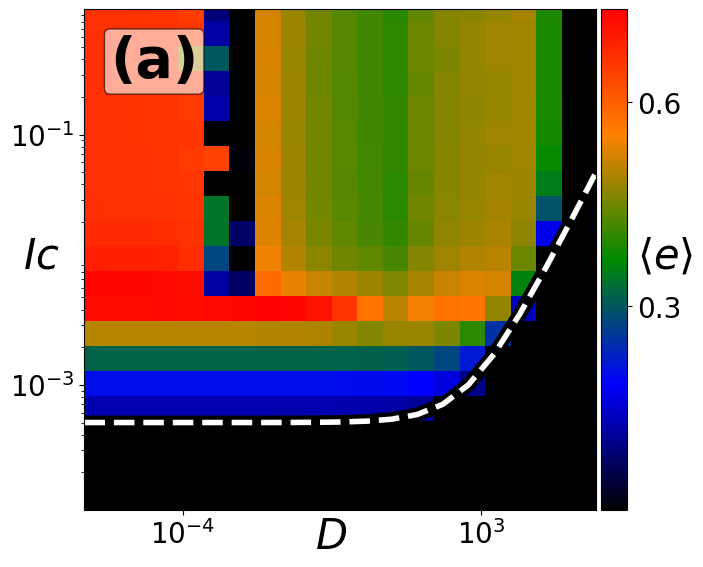

In [34]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Crear figura y eje
fig, ax = plt.subplots(figsize=(7, 6.5))

# Colocar los textos en las posiciones correspondientes
ax.text(0.05, 0.95, '(a)', fontsize=40, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6, edgecolor='black', boxstyle='round,pad=0.1'))
ax.text(0.45, -0.01, r'$D$', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')
ax.text(-0.12, 0.55, r'$Ic$', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')
ax.text(1.08, 0.55, r'$ \langle e \rangle $', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')

xticks = ax.get_xticks()
ax.set_xticklabels([f'{tick:.1f}' for tick in xticks], fontsize=12
                   #, bbox=dict(facecolor='white', edgecolor='black', pad=3)
                  )
# Personalizar las etiquetas de los ticks del eje y con un recuadro de fondo
yticks = ax.get_yticks()
ax.set_yticklabels([f'{tick:.1f}' for tick in yticks], fontsize=12
                  # , bbox=dict(facecolor='white', edgecolor='black', pad=3)
                  )

# Graficar el heatmap
heatmap = ax.pcolormesh(D_grid, Ic_grid, A1_matrix, cmap=cmap)

ax.plot(D_grid, Ic1, color='black', linestyle='-', lw=10)
ax.plot(D_grid, Ic1, color='white', linestyle='--', lw=4)
#ax.plot(Dc2, Ic_grid, color='black', linestyle='-', lw=10)
#ax.plot(Dc2, Ic_grid, color='white', linestyle='--', lw=4)

# Dividir el eje para la barra de color
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)  # Tamaño y espacio de la colorbar

# Añadir la barra de color
colorbar = fig.colorbar(heatmap, cax=cax)
colorbar.ax.tick_params(labelsize=20)
colorbar.set_ticks([0.3, 0.6])

#ax.plot(v0c, Dt_grid, color='black', linestyle='-', lw=10)
#ax.plot(v0c, Dt_grid, color='white', linestyle='--', lw=4)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([D_grid[0],D_grid[-1]])
ax.set_ylim([Ic_grid[0],Ic_grid[-1]])
ax.set_xticks([1e-4, 1000])
ax.set_yticks([1e-3, 0.1])
ax.tick_params(labelsize=20)

plt.savefig("IC_am.pdf", format="pdf", transparent=True, bbox_inches="tight")
plt.show()

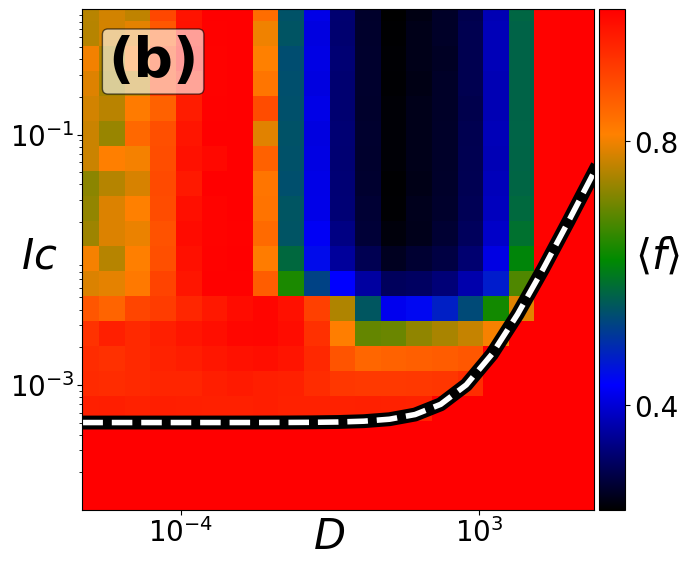

In [28]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Crear figura y eje
fig, ax = plt.subplots(figsize=(7, 6.5))

# Colocar los textos en las posiciones correspondientes
ax.text(0.05, 0.95, '(b)', fontsize=40, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6, edgecolor='black', boxstyle='round,pad=0.1'))
ax.text(0.45, -0.01, r'$D$', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')
ax.text(-0.12, 0.55, r'$Ic$', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')
ax.text(1.08, 0.55, r'$ \langle f \rangle $', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')

ax.set_xticks([1e-4, 1000])
ax.set_yticks([1e-4, 0.01])
ax.tick_params(labelsize=20, direction='out', pad=2)

xticks = ax.get_xticks()
ax.set_xticklabels([f'{tick:.1f}' for tick in xticks], fontsize=12
                   #, bbox=dict(facecolor='white', edgecolor='black', pad=3)
                  )
# Personalizar las etiquetas de los ticks del eje y con un recuadro de fondo
yticks = ax.get_yticks()
ax.set_yticklabels([f'{tick:.1f}' for tick in yticks], fontsize=12
                  # , bbox=dict(facecolor='white', edgecolor='black', pad=3)
                  )

# Graficar el heatmap
heatmap = ax.pcolormesh(D_grid, Ic_grid, E1_matrix, cmap=cmap)

ax.plot(D_grid, Ic1, color='black', linestyle='-', lw=10)
ax.plot(D_grid, Ic1, color='white', linestyle='--', lw=4)
#ax.plot(D_grid, Ic2, color='black', linestyle='-', lw=10)
#ax.plot(D_grid, Ic2, color='white', linestyle='--', lw=4)

# Dividir el eje para la barra de color
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)  # Tamaño y espacio de la colorbar

# Añadir la barra de color
colorbar = fig.colorbar(heatmap, cax=cax)
colorbar.ax.tick_params(labelsize=20)
colorbar.set_ticks([0.4, 0.8])

#ax.plot(v0c, Dt_grid, color='black', linestyle='-', lw=10)
#ax.plot(v0c, Dt_grid, color='white', linestyle='--', lw=4)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([D_grid[0],D_grid[-1]])
ax.set_ylim([Ic_grid[0],Ic_grid[-1]])
ax.set_xticks([1e-4, 1000])
ax.set_yticks([1e-3, 0.1])
ax.tick_params(labelsize=20)

plt.savefig("IC_em.pdf", format="pdf", transparent=True, bbox_inches="tight")
plt.show()

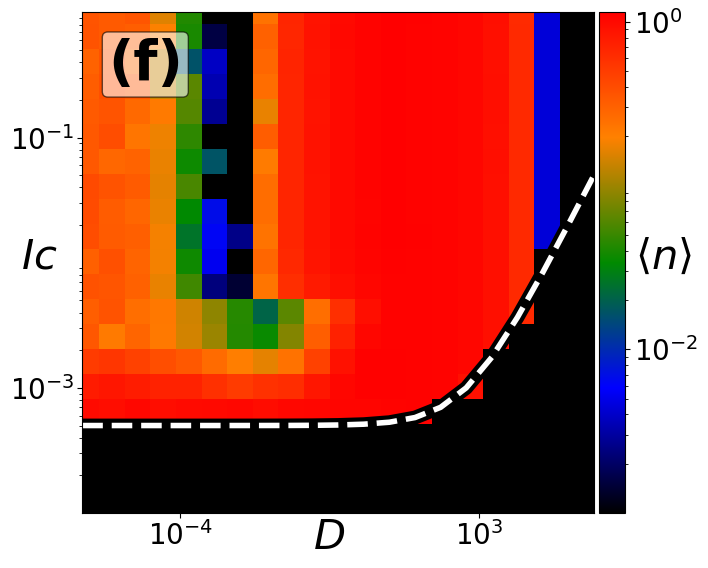

In [22]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Crear figura y eje
fig, ax = plt.subplots(figsize=(7, 6.5))

# Colocar los textos en las posiciones correspondientes
ax.text(0.05, 0.95, '(f)', fontsize=40, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6, edgecolor='black', boxstyle='round,pad=0.1'))
ax.text(0.45, -0.01, r'$D$', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')
ax.text(-0.12, 0.55, r'$Ic$', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')
ax.text(1.08, 0.55, r'$ \langle n \rangle $', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')

ax.set_xticks([1e-4, 1000])
ax.set_yticks([1e-4, 0.01])
ax.tick_params(labelsize=20, direction='out', pad=2)

xticks = ax.get_xticks()
ax.set_xticklabels([f'{tick:.1f}' for tick in xticks], fontsize=12
                   #, bbox=dict(facecolor='white', edgecolor='black', pad=3)
                  )
# Personalizar las etiquetas de los ticks del eje y con un recuadro de fondo
yticks = ax.get_yticks()
ax.set_yticklabels([f'{tick:.1f}' for tick in yticks], fontsize=12
                  # , bbox=dict(facecolor='white', edgecolor='black', pad=3)
                  )

from matplotlib.colors import LogNorm  # Importar LogNorm
N1_na = np.array(N1_matrix)
N1_na[ ~(N1_na > 1e-3)] = 1e-3  # Sustituir valores cero o negativos por un valor muy pequeño

# Crear el heatmap con escala logarítmica para los colores
heatmap = ax.pcolormesh(D_grid, Ic_grid, N1_na, cmap=cmap, norm=LogNorm())

ax.plot(D_grid, Ic1, color='black', linestyle='-', lw=10)
ax.plot(D_grid, Ic1, color='white', linestyle='--', lw=4)
#ax.plot(D_grid, Ic2, color='black', linestyle='-', lw=10)
#ax.plot(D_grid, Ic2, color='white', linestyle='--', lw=4)

# Dividir el eje para la barra de color
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)  # Tamaño y espacio de la colorbar

# Añadir la barra de color
colorbar = fig.colorbar(heatmap, cax=cax)
colorbar.ax.tick_params(labelsize=20)
colorbar.set_ticks([0.01,1])

#ax.plot(v0c, Dt_grid, color='black', linestyle='-', lw=10)
#ax.plot(v0c, Dt_grid, color='white', linestyle='--', lw=4)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([D_grid[0],D_grid[-1]])
ax.set_ylim([Ic_grid[0],Ic_grid[-1]])
ax.set_xticks([1e-4, 1000])
ax.set_yticks([1e-3, 0.1])
ax.tick_params(labelsize=20)

plt.savefig("IC_Nm.pdf", format="pdf", transparent=True, bbox_inches="tight")
plt.show()

NameError: name 'Is_grid' is not defined

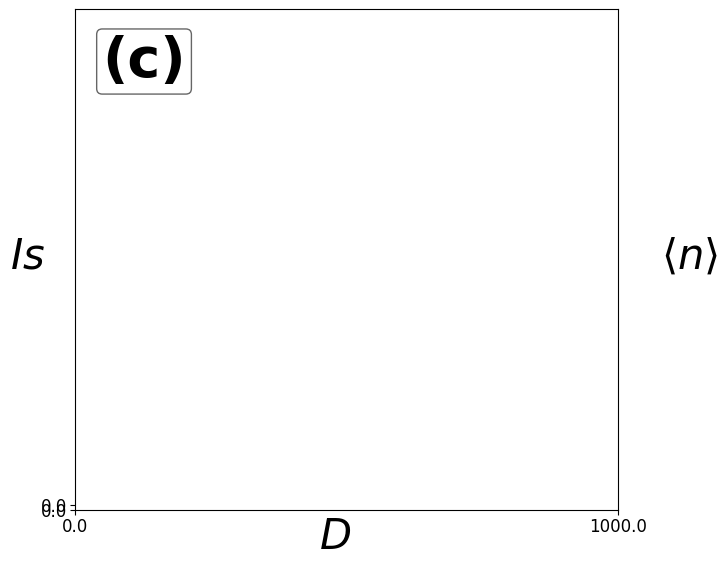

In [21]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Crear figura y eje
fig, ax = plt.subplots(figsize=(7, 6.5))

# Colocar los textos en las posiciones correspondientes
ax.text(0.05, 0.95, '(c)', fontsize=40, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6, edgecolor='black', boxstyle='round,pad=0.1'))
ax.text(0.45, -0.01, r'$D$', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')
ax.text(-0.12, 0.55, r'$Is$', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')
ax.text(1.08, 0.55, r'$ \langle n \rangle $', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')

ax.set_xticks([1e-4, 1000])
ax.set_yticks([1e-4, 0.01])
ax.tick_params(labelsize=20, direction='out', pad=2)

xticks = ax.get_xticks()
ax.set_xticklabels([f'{tick:.1f}' for tick in xticks], fontsize=12
                   #, bbox=dict(facecolor='white', edgecolor='black', pad=3)
                  )
# Personalizar las etiquetas de los ticks del eje y con un recuadro de fondo
yticks = ax.get_yticks()
ax.set_yticklabels([f'{tick:.1f}' for tick in yticks], fontsize=12
                  # , bbox=dict(facecolor='white', edgecolor='black', pad=3)
                  )

from matplotlib.colors import LogNorm  # Importar LogNorm
N1_na = np.array(N1_matrix)
N1_na[N1_na <= 0] = 1e-3  # Sustituir valores cero o negativos por un valor muy pequeño

# Crear el heatmap con escala logarítmica para los colores
heatmap = ax.pcolormesh(D_grid, Is_grid, N1_na, cmap=cmap, norm=LogNorm())

ax.plot(D_grid, Is1, color='black', linestyle='-', lw=10)
ax.plot(D_grid, Is1, color='white', linestyle='--', lw=4)
ax.plot(D_grid, Is2, color='black', linestyle='-', lw=10)
ax.plot(D_grid, Is2, color='white', linestyle='--', lw=4)

# Dividir el eje para la barra de color
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)  # Tamaño y espacio de la colorbar

# Añadir la barra de color
colorbar = fig.colorbar(heatmap, cax=cax)
colorbar.ax.tick_params(labelsize=20)
colorbar.set_ticks([0.01, 1])  # Asegúrate de ajustar los ticks a la escala logarítmica si es necesario

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([D_grid[0],D_grid[-1]])
ax.set_ylim([Is_grid[0],Is_grid[-1]])
ax.set_xticks([1e-4, 1000])
ax.set_yticks([1e-3, 0.1])
ax.tick_params(labelsize=20)

plt.savefig("KR_Nm.pdf", format="pdf", transparent=True, bbox_inches="tight")
plt.show()